# Demand Pulse — M5 Walmart (real sales)

Nordstrom-style demand-plan portfolio demo on **public M5 Forecasting Accuracy** (Walmart) data.

- **System plan (locked):** pure trailing 28-day mean of prior days — **won** this holdout
- **Challenge (notebook only):** 50/50 same-weekday-last-year + trail-28 — **lost** (level drift)
- **Holdout:** last 28 days of evaluation series (2016-04-25 → 2016-05-22)
- **Inventory:** simulated weekly reorder-to-cover (M5 has no on-hand)
- **No** neural nets / Prophet / XGBoost / LightGBM

**Disclaimer:** Public M5 Walmart sales data (Kaggle) for a portfolio demo. Inventory cover is simulated with a simple reorder policy — not real on-hand. Not affiliated with Walmart, Nordstrom, or any retailer.


In [1]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/workspace/demand-pulse-m5')
PROC, OUT = ROOT / 'data' / 'processed', ROOT / 'out'
TRAIL_DAYS, YOY_LAG_DAYS = 28, 364
YOY_WEIGHT = TRAIL_WEIGHT = 0.50
HOLDOUT_DAYS = 28
START_COVER_WEEKS = TARGET_COVER_WEEKS = 3.0
OVERSTOCK_WOS = 4.0
SCENARIO_LIFT, SCENARIO_CAT = 0.10, 'FOODS'

filter_meta = json.loads((PROC / 'filter_meta.json').read_text())
print('Filter:', filter_meta['filter']['description'])
print('Rows:', filter_meta['row_counts'])
print('Dates:', filter_meta['date_range'])


Filter: 3 California stores (CA_1, CA_2, CA_3) × top 80 items by total unit volume across those stores over d_1..d_1941
Rows: {'daily_rows': 465840, 'series': 240, 'stores': 3, 'items': 80, 'price_rows': 63058}
Dates: {'min': '2011-01-29', 'max': '2016-05-22', 'n_days': 1941}


## Load filtered extract & build plans

**System plan = trailing 28-day mean** (locked winner). Challenge = 50/50 YoY blend (loser on this holdout). Built daily; locked WMAPE/bias use weekly rollups.


In [2]:

df = pd.read_parquet(PROC / 'm5_ca3_top80_daily.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)

def build_plans(frame):
    out = []
    for (_, _), g in frame.groupby(['store_id', 'item_id'], sort=False):
        g = g.copy()
        s = g['sales'].astype(float)
        yoy = s.shift(YOY_LAG_DAYS)
        trail = s.shift(1).rolling(TRAIL_DAYS, min_periods=7).mean()
        # SYSTEM = pure trail-28 (winner)
        g['plan'] = trail.clip(lower=0)
        # CHALLENGE = 50/50 YoY + trail (loser)
        blend = YOY_WEIGHT * yoy + TRAIL_WEIGHT * trail
        blend = blend.where(yoy.notna(), trail)
        g['plan_challenge'] = blend.clip(lower=0)
        g['plan_yoy'] = yoy
        g['plan_trail28'] = trail
        out.append(g)
    return pd.concat(out, ignore_index=True)

df = build_plans(df)
holdout_max = df['date'].max()
holdout_min = holdout_max - pd.Timedelta(days=HOLDOUT_DAYS - 1)
hold = df[(df['date'] >= holdout_min) & (df['date'] <= holdout_max) & df['plan'].notna()].copy()
print(f'Holdout {holdout_min.date()} → {holdout_max.date()} | daily rows {len(hold)} | series {hold.groupby(["store_id","item_id"]).ngroups}')
print('Events in holdout:')
print(hold.loc[hold['event_name_1'].notna(), ['date','event_name_1','event_type_1']].drop_duplicates().to_string(index=False))


Holdout 2016-04-25 → 2016-05-22 | daily rows 6720 | series 240
Events in holdout:
      date   event_name_1 event_type_1
2016-04-30     Pesach End    Religious
2016-05-01 OrthodoxEaster    Religious
2016-05-05  Cinco De Mayo     Cultural
2016-05-08   Mother's day     Cultural


In [3]:

def wmape(y, f):
    y, f = np.asarray(y, float), np.asarray(f, float)
    m = np.isfinite(y) & np.isfinite(f)
    y, f = y[m], f[m]
    d = np.abs(y).sum()
    return float(np.abs(y - f).sum() / d) if d else float('nan')

def bias_pct(y, f):
    y, f = np.asarray(y, float), np.asarray(f, float)
    m = np.isfinite(y) & np.isfinite(f)
    y, f = y[m], f[m]
    d = y.sum()
    return float((f - y).sum() / d) if d else float('nan')

hold['week'] = hold['date'].dt.to_period('W-SUN').dt.start_time
hold_w = hold.groupby(['store_id','item_id','dept_id','cat_id','week'], as_index=False).agg(
    sales=('sales','sum'), plan=('plan','sum'), plan_challenge=('plan_challenge','sum'),
    sell_price=('sell_price','mean'))

wmape_sys = wmape(hold_w['sales'], hold_w['plan'])
bias_sys = bias_pct(hold_w['sales'], hold_w['plan'])
wmape_chal = wmape(hold_w['sales'], hold_w['plan_challenge'])
bias_chal = bias_pct(hold_w['sales'], hold_w['plan_challenge'])
print(f'System plan trail-28 (weekly): WMAPE={wmape_sys*100:.2f}%  bias={bias_sys*100:.2f}%  ← LOCKED')
print(f'Challenge 50/50 YoY blend:     WMAPE={wmape_chal*100:.2f}%  bias={bias_chal*100:.2f}%  ← LOST (level drift)')
assert wmape_sys < wmape_chal, 'trail should beat blend on this holdout'
print('Locked the simple method that won.')


System plan trail-28 (weekly): WMAPE=19.87%  bias=0.67%  ← LOCKED
Challenge 50/50 YoY blend:     WMAPE=27.45%  bias=-3.46%  ← LOST (level drift)
Locked the simple method that won.


## Simulated inventory (not real Walmart on-hand)

Start = 3 weeks of pre-holdout avg weekly sales. Each week: deplete by actual sales; reorder up to 3 weeks of **trail-28 system plan**; lead time = 1 week.


In [4]:

w = df.copy()
w['week'] = w['date'].dt.to_period('W-SUN').dt.start_time
weekly = w.groupby(['store_id','item_id','dept_id','cat_id','week'], as_index=False).agg(
    sales=('sales','sum'), plan=('plan','sum'), sell_price=('sell_price','mean')
).sort_values(['store_id','item_id','week'])
holdout_week_min = pd.Timestamp(holdout_min.to_period('W-SUN').start_time)
avg_weekly = weekly[weekly['week'] < holdout_week_min].groupby(['store_id','item_id'])['sales'].mean()

inv_rows = []
for (store, item), g in weekly.groupby(['store_id','item_id']):
    g = g.sort_values('week').reset_index(drop=True)
    avg_s = float(avg_weekly.get((store, item), g['sales'].mean()) or 0.0)
    on_hand, incoming = START_COVER_WEEKS * max(avg_s, 0.0), 0.0
    for _, row in g.iterrows():
        on_hand += incoming; incoming = 0.0
        demand = float(row['sales'])
        sold = min(on_hand, demand); unmet = demand - sold; on_hand -= sold
        plan_w = float(row['plan']) if np.isfinite(row['plan']) else avg_s
        order = max(0.0, TARGET_COVER_WEEKS * max(plan_w, 0.0) - on_hand)
        incoming = order
        wos = on_hand / demand if demand > 0 else (np.nan if on_hand <= 0 else 99.0)
        inv_rows.append(dict(store_id=store, item_id=item, dept_id=row['dept_id'], cat_id=row['cat_id'],
                             week=row['week'], sales=demand, plan=plan_w, on_hand_end=on_hand,
                             order=order, unmet=unmet, wos=wos))
inv = pd.DataFrame(inv_rows)
inv['week'] = pd.to_datetime(inv['week'])
last_week = inv['week'].max()
last = inv[inv['week'] == last_week]
avg_wos = float(last.loc[last['sales'] > 0, 'wos'].mean())
overstock = float((last['wos'] > OVERSTOCK_WOS).fillna(False).mean())
hw = inv[inv['week'] >= holdout_week_min]
stockout_rate = float(hw['unmet'].sum() / hw['sales'].sum()) if hw['sales'].sum() else 0.0
print(f'Last week {last_week.date()} | avg WOS={avg_wos:.3f} | overstock(WOS>4)={overstock*100:.1f}% | holdout unmet={stockout_rate*100:.2f}%')


Last week 2016-05-16 | avg WOS=3.248 | overstock(WOS>4)=13.8% | holdout unmet=0.12%


## Scenario — FOODS +10% (Mother's Day week in holdout)


In [5]:

foods = hold[hold['cat_id'] == SCENARIO_CAT]
base_u = float(foods['sales'].sum())
base_rev = float((foods['sales'] * foods['sell_price'].fillna(0)).sum())
delta_u, delta_rev = base_u * SCENARIO_LIFT, base_rev * SCENARIO_LIFT
print(f"FOODS baseline {base_u:,.0f} units / ${base_rev:,.0f}")
print(f"+10% lift → +{delta_u:,.0f} units / +${delta_rev:,.0f}")


FOODS baseline 73,941 units / $148,191
+10% lift → +7,394 units / +$14,819


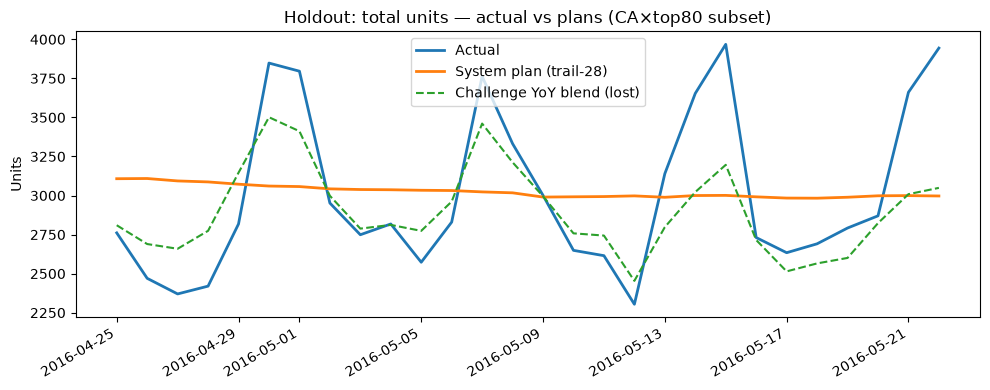

Saved /workspace/demand-pulse-m5/out/holdout_forecast.png


In [6]:

tot = hold.groupby('date', as_index=False).agg(sales=('sales','sum'), plan=('plan','sum'), challenge=('plan_challenge','sum'))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tot['date'], tot['sales'], label='Actual', lw=2)
ax.plot(tot['date'], tot['plan'], label='System plan (trail-28)', lw=2)
ax.plot(tot['date'], tot['challenge'], label='Challenge YoY blend (lost)', ls='--', lw=1.5)
ax.set_title('Holdout: total units — actual vs plans (CA×top80 subset)')
ax.set_ylabel('Units')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / 'holdout_forecast.png', dpi=120)
plt.show()
print('Saved', OUT / 'holdout_forecast.png')


## Locked board KPIs (from `out/board_data.json`)


In [7]:

board = json.loads((OUT / 'board_data.json').read_text())
for k, t in board['tiles'].items():
    print(f"{k}: {t['value']} — {t['plain']}")
print('Scenario:', board['scenario']['plain'])
print('System:', board['meta']['methods']['system_plan'][:120], '...')
print('Challenge:', board['meta']['methods']['challenge_check'][:140], '...')
print('Exceptions:', len(board['exceptions']))
for e in board['exceptions'][:3]:
    print(' ', e['display'], '→', e['action'])
print('Disclaimer:', board['meta']['disclaimer'])


wmape_system: 19.87 — Plan missed sales by 20%
bias_pct: 0.67 — Plan ran about 1% high
avg_weeks_of_supply: 3.248 — Avg cover about 3 weeks
overstock_share_pct: 13.8 — 1 in 10 items over a month of stock
Scenario: If FOODS sells 10% hotter → +7.4k units / ~$15k — check whether stock can cover it
System: Pure trailing 28-day mean of prior days (no leakage). Built daily; locked WMAPE/bias scored on weekly rollups. Won this  ...
Challenge: 50/50 same-weekday-last-year (364-day lag) + trailing 28-day mean, weekly rollup (notebook only): 27.4% WMAPE / -3.5% bias — LOST to the pur ...
Exceptions: 8
  FOODS_3_362 · Foods / FOODS_3 · CA store 3 (CA_3) → Trim the next order — plan has been running high here.
  FOODS_3_234 · Foods / FOODS_3 · CA store 2 (CA_2) → Trim the next order — plan has been running high here.
  HOUSEHOLD_1_334 · Household / HOUSEHOLD_1 · CA store 1 (CA_1) → Trim the next order — plan high and cover is already over a month.
Disclaimer: Public M5 Walmart sales data (Kaggle)